In [2]:
#Importing Important Stuff
import os
import cv2
import sys
import math
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import scipy.interpolate
import scipy.signal
import sklearn.cluster
import fmEphys as fme
import pickle



Loading DLC 2.3.0...


In [3]:
def read_binary_file(self, do_remap=True):
        """ Read the ephys binary file and remap channels.

        Parameters
        ----------
        do_remap : bool
            If True, remap channels into their physically meaningful
            order. If False, keep the channels in the order they were
            recorded.
        
        Returns
        -------
        ephys : pd.DataFrame
            Ephys data with shape (time, channel).
        
        """

        # Open channel map file
        with open(self.channel_map_path, 'r') as fp:
            all_maps = json.load(fp)
            
        # Get channel map for this probe
        ch_map = all_maps[self.probe]['map']
        num_ch = all_maps[self.probe]['nCh']
        
        # Set up data types to read binary file into
        dtypes = np.dtype([('ch'+str(i),np.uint16) for i in range(0,num_ch)])
        
        # Read in binary file
        ephys = pd.DataFrame(np.fromfile(self.ephys_bin_path, dtypes, -1, ''))
        
        if do_remap:
            # Remap with known order of channels
            ephys = ephys.iloc[:,[i-1 for i in list(ch_map)]]

        return ephys


In [4]:
def butter_bandpass(self, lfp, lowcut=1, highcut=300, fs=30000, order=5):
        """ Apply bandpass filter to ephys LFP along time dimension.

        Parameters
        ----------
        lfp : np.array
            Ephys LFP with shape (time, channel).
        lowcut : int
            Low end of frequency cut off.
        highcut : int
            High end of frequency cut off.
        fs : int
            Sample rate.
        order : int
            Order of filter.

        Returns
        -------
        filt : np.array
            Filtered data with shape (time, channel).

        """

        # Nyquist frequency
        nyq = 0.5 * fs 

        # Low cutoff
        low = lowcut / nyq

        # High cutoff
        high = highcut / nyq

        # Apply butterworth filter.
        sos = scipy.signal.butter(order,
                                  [low, high],
                                  btype='bandpass', output='sos')
        
        # Apply filter forward and backward to avoid phase shift.
        filt = scipy.signal.sosfiltfilt(sos, lfp, axis=0)

        return filt

In [5]:
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']


In [74]:
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2022\112322\G6CK7GLN',
                  r'D:\022223\J629LN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\053123\G6CK8hLN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\080123\G6Ck9DTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']


In [6]:
Depth = pd.DataFrame()
RC_L5_df = pd.DataFrame()
WN_L5_Channels = np.zeros([4,len(RecordingsToUse)])
RC_L5_Channels = np.zeros([len(RecordingsToUse)])
rr =  0 

test_chnl = np.tile(np.arange(0,32,1),4)
for RecordingPath in RecordingsToUse:
    print(RecordingPath)
    zz = 0
    zzz = 0
    #Finding Single Unit .npy file for each recording
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
            SU_File = (RecordingPath +'/' + Items)

    for WN_subfolder in os.listdir(RecordingPath):
        if zz == 0:
            if WN_subfolder.endswith("wn"):
                for WN_subfolderFiles in os.listdir(RecordingPath +'/' + WN_subfolder):
                    if WN_subfolderFiles.endswith("ephys_props.h5"):
                        WN_Files = (RecordingPath + '/' + WN_subfolder + '/' + WN_subfolderFiles)
                        zz = zz+1

    for RC_subfolder in os.listdir(RecordingPath):
        if zzz == 0:
            if RC_subfolder.endswith(("revchecker", "revchecker500")):
                for RC_subfolderFiles in os.listdir(RecordingPath +'/' + RC_subfolder):
                    if RC_subfolderFiles.endswith("ephys_props.h5"):
                        RC_Files = (RecordingPath + '/' + RC_subfolder + '/' + RC_subfolderFiles)
                        zzz = zzz+1
    
    Single_Units = np.load(SU_File)
    data_wn = pd.read_hdf(WN_Files)
    data_rc = pd.read_hdf(RC_Files)
    doink = 0
    Chnl_Relative_Distances = 25*(np.arange(0,128,1)%32)
    for ii in Single_Units:
        LFP_Chnl = data_wn.loc[ii,'Wn_layer5cent_from_lfp']
        SU_Chnl = data_wn.loc[ii,'Wn_ch']
        #Chnl = data_wn.loc[ii,'Wn_ch']
        SU_Shank = int(np.floor(SU_Chnl/32))
        LFP_Chnl_ToUse= LFP_Chnl[SU_Shank]
        #L5_Chnl = LFP_Chnl[Shank]
        #Ch_Spacing = 25
        #Ch_Depth = Ch_Spacing*(Chnl%32) - (L5_Chnl*Ch_Spacing)
        #data_wn.at[ii,'Wn_depth_from_layer5'] = Ch_Depth

        data_wn.at[ii,'Wn_depth_from_layer5'] = Chnl_Relative_Distances[SU_Chnl] - Chnl_Relative_Distances[LFP_Chnl_ToUse]
        ############


    WN_L5_Channels[:,rr] = data_wn.loc[data_wn.index[0],'Wn_layer5cent_from_lfp']
    rr = rr + 1

    Depth_temp = data_wn.loc[Single_Units,'Wn_depth_from_layer5']
    Depth = pd.concat([Depth, Depth_temp])
    
    
#Depth_Data_wn = pd.read_hdf(r"D:\PrePostDOI\DOI Data_wnsets\DepthAnalysis_GazeShifts_DOI.h5")
#Depth_Data_wn['Depth_from_L5'] = Depth.iloc[:,0].tolist()

#Depth_Data_wn.to_hdf("D:\PrePostDOI\DOI Data_wnsets\DepthAnalysis_GazeShifts_DOI.h5", 'w')


\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2024\022024\G6CK10DTT
D:\072624\J708LT
D:\080224\J705RT
D:\081024\J720LT
\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT
\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT
\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT
\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT


In [12]:
DepthData = pd.read_hdf("D:\PrePostDOI\DOI Datasets\DepthAnalysis_GazeShifts_DOI.h5", 'w')
np.shape(Depth)

(783, 1)

In [11]:
DepthData.columns

Index(['Mouse', 'Cell', 'Contamination_Idx', 'Pre_Responsive',
       'Post_Responsive', 'Pre_Gaze_DS', 'Post_Gaze_DS', 'Pre_Left_Gaze',
       'Pre_Right_Gaze', 'Post_Left_Gaze', 'Post_Right_Gaze', 'Pre_Pref_Gaze',
       'Post_Pref_Gaze', 'Pre_NonPref_Gaze', 'Post_NonPref_Gaze',
       'Pre_Pref_Gaze_Times', 'Post_Pref_Gaze_Times', 'Pre_NonPref_Gaze_Times',
       'Post_NonPref_Gaze_Times', 'Pre_SpikeT', 'Post_SpikeT'],
      dtype='object')

In [17]:
DepthData = pd.read_hdf("D:\PrePostDOI\DOI Datasets\DepthAnalysis_GazeShifts_DOI.h5", 'w')
DOI_NotContaminted = np.where(DepthData.loc[:,'Contamination_Idx']<=30)
#DepthData = DepthData.iloc[DOI_NotContaminted]
#Depth = Depth.iloc[DOI_NotContaminted]

Mice = np.unique(DepthData.loc[:,'Mouse'])
DepthByMouse = []

for ii in range(0,len(Mice)):
    Mouse = Mice[ii]
    Mouse_Idxes = np.where(Mouse == DepthData.loc[:,'Mouse'])
    DepthByMouse.append(Mouse_Idxes)


([<matplotlib.axis.YTick at 0x2025feede80>,
 [Text(0, 0, '0'),
  Text(0, 4, '4'),
  Text(0, 8, '8'),
  Text(0, 12, '12'),
  Text(0, 16, '16'),
  Text(0, 20, '20'),
  Text(0, 24, '24'),
  Text(0, 28, '28'),
  Text(0, 32, '32')])

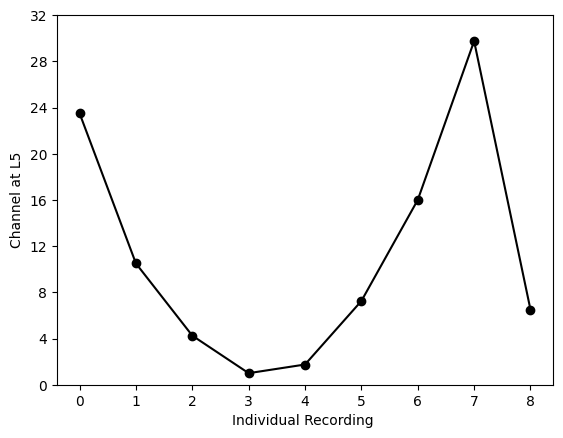

In [175]:
plt.plot(np.nanmean(WN_L5_Channels,axis=0),'ko-')
plt.ylabel('Channel at L5')
plt.xlabel('Individual Recording ')
plt.ylim(0,32)
plt.yticks(np.arange(0,36,4))


In [114]:
print(np.sum(Depth >=  0))
print(np.sum(Depth <  0))

0    405
dtype: int64
0    75
dtype: int64


([<matplotlib.axis.XTick at 0x201aef29bb0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8')])

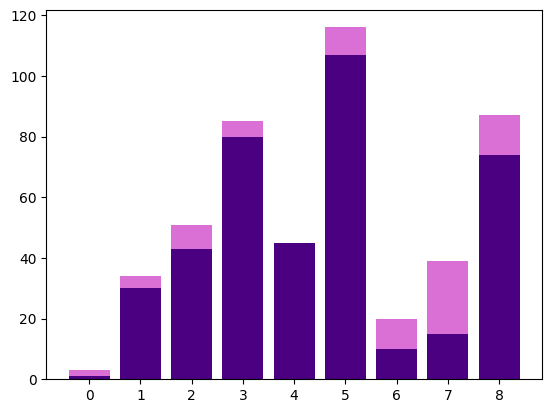

In [115]:
ii =0
for ii in range(0,len(DepthByMouse)):
    temp = Depth.iloc[DepthByMouse[ii]]
    #print(np.sum(temp >=  0))
    #print(np.sum(temp <  0))
    #print(len(temp))

    plt.bar(ii, np.sum(temp >=  0), color = 'indigo')
    plt.bar(ii, np.sum(temp <  0), bottom = np.sum(temp >=  0), color = 'orchid')
plt.xticks(np.arange(0,9,1))

In [34]:
print(np.shape(Depth))
np.shape(Depth.iloc[DOI_NotContaminted])

(783, 1)


(480, 1)

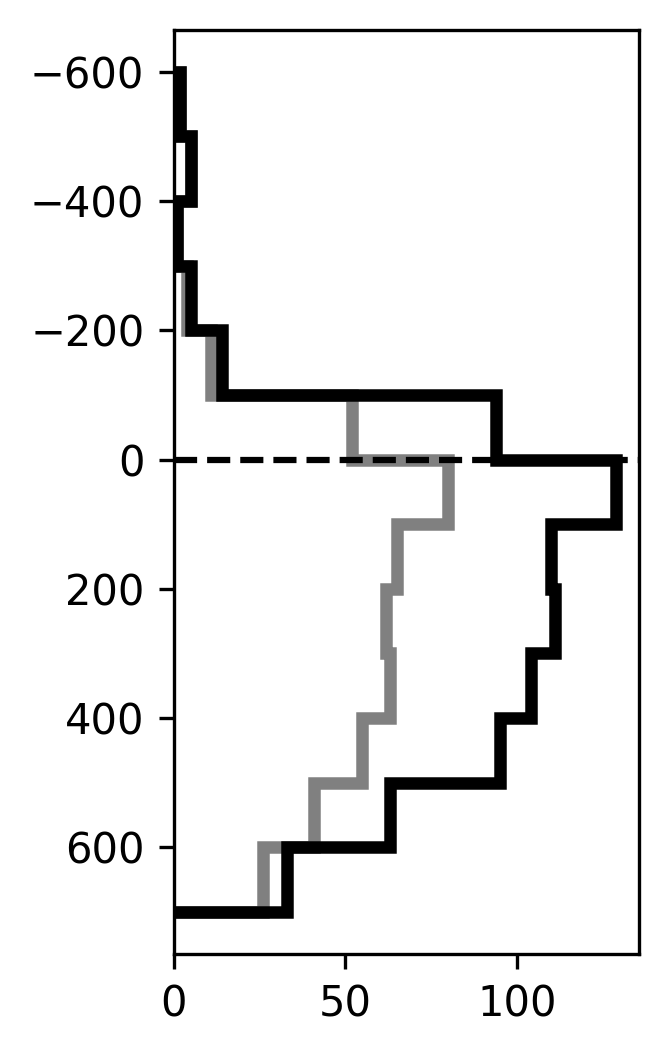

In [22]:
bins = np.arange(-600,800,100)
Depth #= np.stack(Depth.loc[:,'Depth_from_L5'])
weights = np.ones_like(Depth)/float(len(Depth))
fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
plt.hist(Depth.iloc[DOI_NotContaminted],bins,orientation= 'horizontal',histtype = 'step',color = 'grey',linewidth = 3)
plt.hist(Depth,bins,orientation= 'horizontal',histtype = 'step',color = 'black',linewidth = 3)
plt.axhline(0,color = 'black',linestyle='--')

plt.gca().invert_yaxis()
#plt.xlim(0,.2)

In [194]:
Depth_Data.columns

Index(['Mouse', 'Cell', 'Pre_Responsive', 'Post_Responsive', 'Pre_Gaze_DS',
       'Post_Gaze_DS', 'Pre_Left_Gaze', 'Pre_Right_Gaze', 'Post_Left_Gaze',
       'Post_Right_Gaze', 'Pre_Pref_Gaze', 'Post_Pref_Gaze',
       'Pre_NonPref_Gaze', 'Post_NonPref_Gaze', 'Pre_Pref_Gaze_Times',
       'Post_Pref_Gaze_Times', 'Pre_NonPref_Gaze_Times',
       'Post_NonPref_Gaze_Times', 'Pre_SpikeT', 'Post_SpikeT',
       'Depth_from_L5'],
      dtype='object')

In [24]:
####Adding Gaze Cluster type to dataset

PreDOI_Gaze = np.stack(Depth_Data.loc[:,'Pre_Pref_Gaze'])
PostDOI_Gaze = np.stack(Depth_Data.loc[:,'Post_Pref_Gaze'])

PreDOI_Max = np.nanmax(PreDOI_Gaze,axis=1)
PostDOI_Max = np.nanmax(PostDOI_Gaze,axis=1)
Mx = np.nanmax([PreDOI_Max,PostDOI_Max],axis=0)

PreDOI_Gaze_Based = PreDOI_Gaze - np.nanmean(PreDOI_Gaze[:,100:750],axis=1)[:,None]
PostDOI_Gaze_Based = PostDOI_Gaze - np.nanmean(PostDOI_Gaze[:,100:750],axis=1)[:,None]

PreDOI_Gaze_Norm = PreDOI_Gaze_Based/Mx[:,None]
PostDOI_Gaze_Norm = PostDOI_Gaze_Based/Mx[:,None]


#
Pre_Responsive = np.stack(Depth_Data.loc[:,'Pre_Responsive'])
Post_Responsive = np.stack(Depth_Data.loc[:,'Post_Responsive'])

Responsive = (Pre_Responsive + Post_Responsive)-1
Responsive[Responsive<0] = 0
Responsive = Responsive.astype(bool)


PreDOI_Gaze_4Clustering = PreDOI_Gaze_Norm
PreDOI_Gaze_4Clustering[Pre_Responsive ==0] = 0
PostDOI_Gaze_4Clustering = PostDOI_Gaze_Norm
PostDOI_Gaze_4Clustering[Post_Responsive ==0] = 0

import fmEphys as fme
import pickle

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)


proj = pca.transform(PreDOI_Gaze_4Clustering[:, 950:1300])  # Transform into PC space.
gproj = proj[:,:4]  # Only keep required PCs
PreDOI_Labels = kmeans_model.predict(gproj)  # Map onto k-means clusters.

projpost = pca.transform(PostDOI_Gaze_4Clustering[:, 950:1300])
gprojpost = projpost[:,:4]
PostDOI_Labels = kmeans_model.predict(gprojpost)

Depth_Data['KMeans_Cluster_Pre'] = PreDOI_Labels 
Depth_Data['KMeans_Cluster_Post'] = PostDOI_Labels

Depth_Data.to_hdf("D:\PrePostDOI\DOI Datasets\DepthAnalysis_GazeShifts_DOI.h5", 'w')

NameError: name 'Depth_Data' is not defined

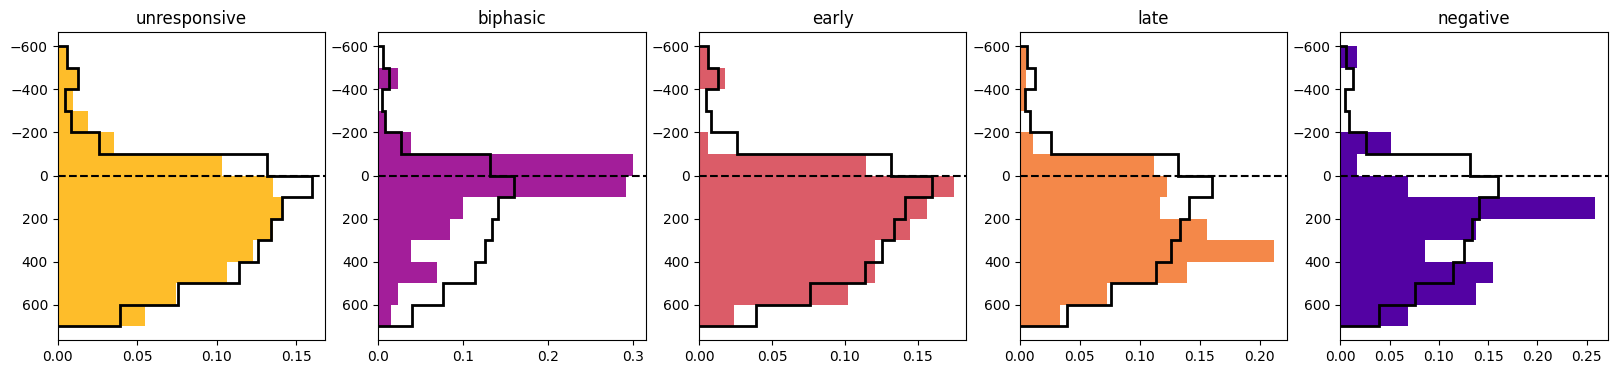

In [230]:
plasma_map = plt.cm.plasma(np.linspace(0,1,15))
clr = [plasma_map[12, :], plasma_map[5,:], plasma_map[8, :], plasma_map[10, :], plasma_map[2, :]]


fig, ax = plt.subplots(1,5, figsize=(20,4), dpi=100)
ax = ax.ravel()

titles = ['unresponsive','biphasic','early','late','negative']
pop_weights = np.ones(len(Depth))/len(Depth)
for ii in range(0,5):
    group_weights  = np.ones(len(np.argwhere(PreDOI_Labels == ii)))/len(np.argwhere(PreDOI_Labels == ii))
    ax[ii].hist(Depth[np.argwhere(PreDOI_Labels == ii)],bins,orientation = 'horizontal',weights = group_weights,color = clr[ii])
    ax[ii].hist(Depth,bins,histtype = 'step',orientation = 'horizontal',color = 'black',linewidth = 2, weights = pop_weights)
    ax[ii].axhline(0,color = 'black',linestyle = '--')
    ax[ii].set_title(titles[ii])
    ax[ii].invert_yaxis()

Text(0, 0.5, 'Depth')

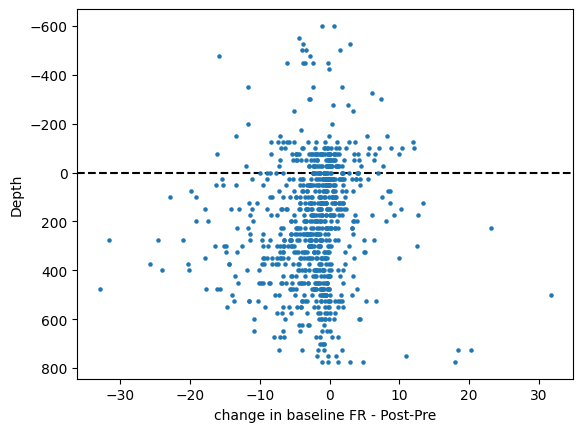

In [259]:
PreDOI_Baseline = np.nanmean(PreDOI_Gaze[:,100:750],axis=1)
PostDOI_Baseline = np.nanmean(PostDOI_Gaze[:,100:750],axis=1)

Baseline_Change = PostDOI_Baseline-PreDOI_Baseline 


plt.axhline(0,color = 'black',linestyle='--',zorder = 3)
plt.scatter(Baseline_Change, Depth,s =5,zorder = 5)
plt.gca().invert_yaxis()
plt.xlabel('change in baseline FR - Post-Pre')
plt.ylabel('Depth')


In [343]:
Shuffled = True
if Shuffled == True:
    print('derp')

derp


In [348]:
def plot_running_median_vert(ax, x, y, n_bins=7, shuffled = False):
    """ Plot median of a dataset along a set of vertical bins.
    
    """

    bins = np.linspace(np.min(y), np.max(y), n_bins)
    
    print(bins)

    bin_means, bin_edges, bin_number = scipy.stats.binned_statistic(y[~np.isnan(x) & ~np.isnan(y)], x[~np.isnan(x) & ~np.isnan(y)], statistic=np.median, bins=bins)
    
    bin_std, _, _ = scipy.stats.binned_statistic(y[~np.isnan(x) & ~np.isnan(y)], x[~np.isnan(x) & ~np.isnan(y)], statistic=np.nanstd, bins=bins)
    
    hist, _ = np.histogram(y[~np.isnan(x) & ~np.isnan(y)], bins=bins)
    
    tuning_err = bin_std / np.sqrt(hist)


    if shuffled == True:
        ax.plot(bin_means,bin_edges[:-1] + (np.median(np.diff(bins))/2),'-', color='r',zorder =5)
    
        ax.fill_betweenx(bin_edges[:-1] + (np.median(np.diff(bins))/2), bin_means-tuning_err, bin_means+tuning_err, color='r', alpha=0.2,zorder =5)
    else:
        ax.plot(bin_means,bin_edges[:-1] + (np.median(np.diff(bins))/2),'-', color='k',zorder =5)
    
        ax.fill_betweenx(bin_edges[:-1] + (np.median(np.diff(bins))/2), bin_means-tuning_err, bin_means+tuning_err, color='k', alpha=0.2,zorder =5)


In [289]:
def plot_running_median(ax, x, y, n_bins=7):
    """ Plot median of a dataset along a set of horizontal bins.
    
    """

    bins = np.linspace(np.min(x), np.max(x), n_bins)

    bin_means, bin_edges, bin_number = scipy.stats.binned_statistic(
        y[~np.isnan(x) & ~np.isnan(y)],
        x[~np.isnan(x) & ~np.isnan(y)],
        statistic=np.median,
        bins=bins)
    
    bin_std, _, _ = scipy.stats.binned_statistic(
        x[~np.isnan(x) & ~np.isnan(y)],
        y[~np.isnan(x) & ~np.isnan(y)],
        statistic=np.nanstd,
        bins=bins)
    
    hist, _ = np.histogram(
        x[~np.isnan(x) & ~np.isnan(y)],
        bins=bins)
    
    tuning_err = bin_std / np.sqrt(hist)

    ax.plot(bin_edges[:-1] + (np.median(np.diff(bins))/2),
               bin_means,
               '-', color='k')
    
    ax.fill_between(bin_edges[:-1] + (np.median(np.diff(bins))/2),
                       bin_means-tuning_err,
                       bin_means+tuning_err,
                       color='k', alpha=0.2)



In [338]:
Shuffled_Baseline = Baseline_Change.copy()
print(Shuffled_Baseline[:10])
np.random.shuffle(Shuffled_Baseline) 
print(Shuffled_Baseline[:10])

[-2.16586944 -0.50723783  0.32802868  0.1028349  -1.14806287  0.62660699
 -7.05565683 -6.7093545  10.32892741  0.76656736]
[-31.66828506  -1.98540172  -1.33331377   1.92885718  -2.5407037
   4.0459385   -0.4644961   -5.57896103  -0.12848398  -0.19412829]


[-600.         -494.23076923 -388.46153846 -282.69230769 -176.92307692
  -71.15384615   34.61538462  140.38461538  246.15384615  351.92307692
  457.69230769  563.46153846  669.23076923  775.        ]


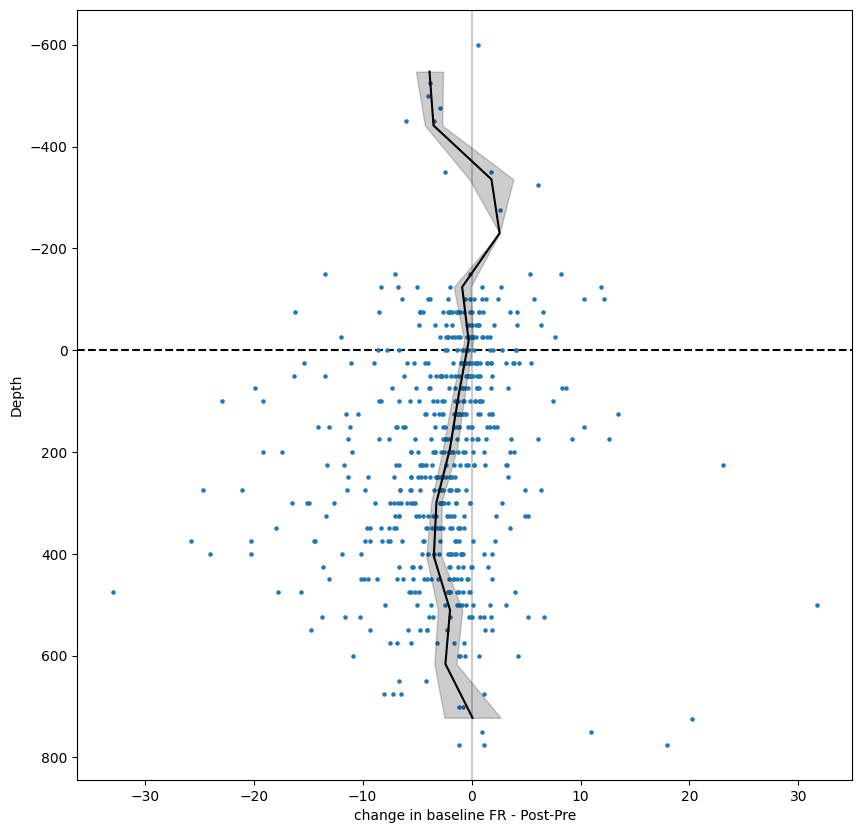

In [350]:
fig, ax = plt.subplots(1,1,figsize=(10,10))
ax.axhline(0,color = 'black',linestyle='--',zorder = 3)
ax.axvline(0,color = 'black',alpha= .2,zorder = 3)
ax.scatter(Baseline_Change[Responsive],Depth[Responsive],s =5,zorder = 4)

plt.gca().invert_yaxis()
plt.xlabel('change in baseline FR - Post-Pre')
plt.ylabel('Depth')
plot_running_median_vert(ax,Baseline_Change[Responsive],Depth[Responsive],n_bins=14)


#plot_running_median_vert(ax,Shuffled_Baseline[Responsive],Depth[Responsive],n_bins=14,shuffled = True)


[-600.         -494.23076923 -388.46153846 -282.69230769 -176.92307692
  -71.15384615   34.61538462  140.38461538  246.15384615  351.92307692
  457.69230769  563.46153846  669.23076923  775.        ]


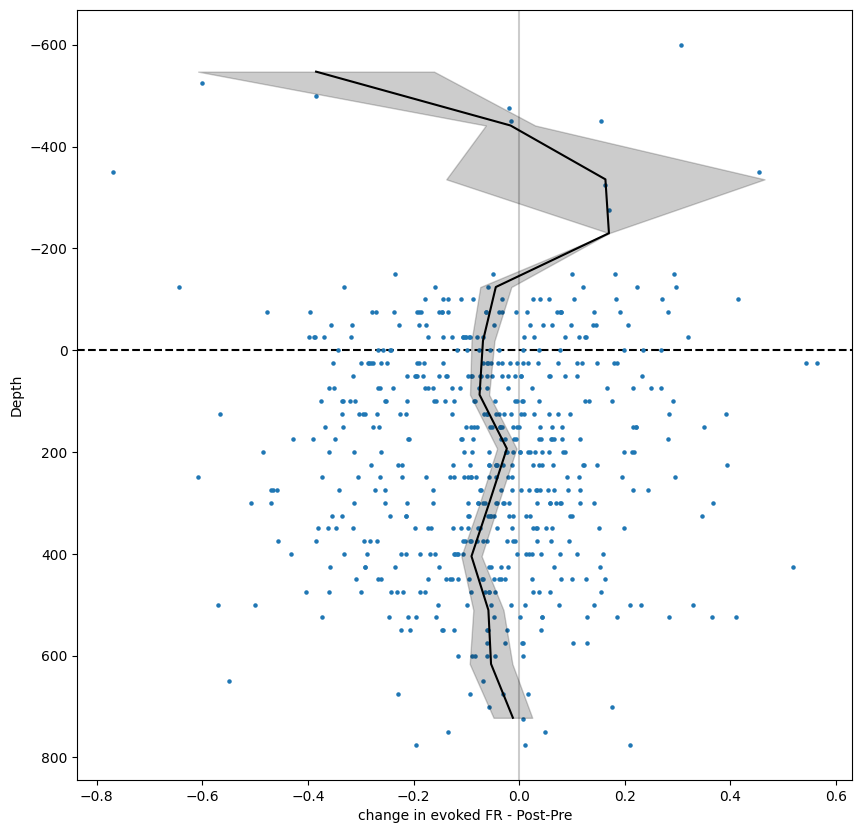

In [318]:
EvokedFR_Change = np.nanmax(PostDOI_Gaze_Norm,axis=1)-np.nanmax(PreDOI_Gaze_Norm,axis=1)

fig, ax = plt.subplots(1,1,figsize=(10,10))
ax.axhline(0,color = 'black',linestyle='--',zorder = 3)
ax.axvline(0,color = 'black',alpha= .2,zorder = 3)
ax.scatter(EvokedFR_Change[Responsive],Depth[Responsive],s =5,zorder = 5)

plt.gca().invert_yaxis()
plt.xlabel('change in evoked FR - Post-Pre')
plt.ylabel('Depth')
plot_running_median_vert(ax,EvokedFR_Change[Responsive],Depth[Responsive],n_bins=14)


[-600.         -494.23076923 -388.46153846 -282.69230769 -176.92307692
  -71.15384615   34.61538462  140.38461538  246.15384615  351.92307692
  457.69230769  563.46153846  669.23076923  775.        ]


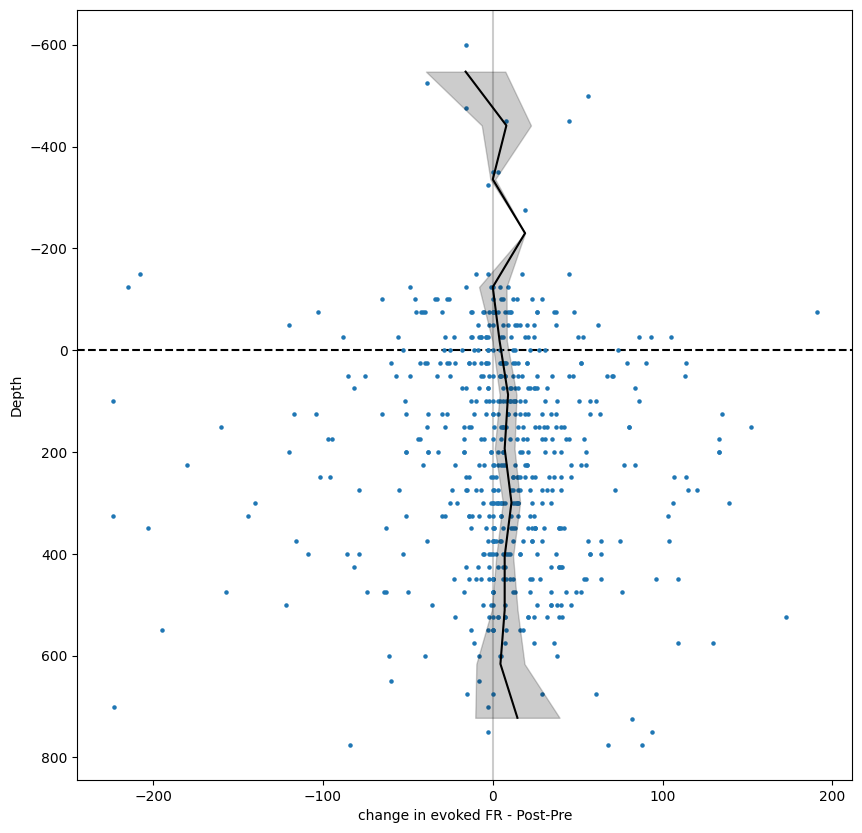

In [319]:
Latency_Change = np.argmax(PostDOI_Gaze[:,1025:1250],axis=1)-np.argmax(PreDOI_Gaze[:,1025:1250],axis=1)

fig, ax = plt.subplots(1,1,figsize=(10,10))
ax.axhline(0,color = 'black',linestyle='--',zorder = 3)
ax.axvline(0,color = 'black',alpha= .2,zorder = 3)
ax.scatter(Latency_Change[Responsive],Depth[Responsive],s =5,zorder = 5)

plt.gca().invert_yaxis()
plt.xlabel('change in evoked FR - Post-Pre')
plt.ylabel('Depth')
plot_running_median_vert(ax,Latency_Change[Responsive],Depth[Responsive],n_bins=14)
